## Goal - Predicting Insurance fraud

### **1. Importing necessary packages**

In [2]:
#data reading and manipulation packages
import numpy as np
import pandas as pd

#data visualization packages
import matplotlib.pyplot as plt
import seaborn as sns

#convert object or labeled data into numeric from processing
from sklearn.preprocessing import LabelEncoder

#machine learning related packages
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

### **2. Reading and exploring the data**



In [3]:
df = pd.read_csv('export.csv')

In [4]:
df.shape

(1000, 39)

In [5]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17 00:00:00,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27 00:00:00,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06 00:00:00,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25 00:00:00,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06 00:00:00,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

## 1.months_as_customer

* Represents the duration (in months) the customer has been associated with the insurance company.
* Numerical feature (`int64`)
---

## 2.age

* Represents the age of the insured customer.
* Numerical feature (`int64`)
---

## 3.policy_bind_date || incident_date || incident_hour_of_the_day

* policy_bind_date -  Represents the date when the insurance policy was initiated.
* incident_date - Represents the date of the incident.
* incident_hour_of_the_day - Represents the hour of the day
---

## 4.umbrella_limit

* Represents the maximum umbrella insurance coverage amount.
* Feature showed strong right-skewness and extreme high-value entries.
* Majority of customers had zero umbrella coverage.

---
## 5.policy_csl
* Represents Combined Single Limit (CSL) in insurance
* CSL is often chosen for better protection against high-cost accidents.

 250/500 means: 
 - $250,000 maximum coverage for bodily injury per individual person.
 - $500,000 maximum coverage total for all bodily injuries combined per accident.
---

## 6.policy_deductible

* Represents the out-of-pocket amount the customer must pay before insurance coverage applies.
* Numerical feature (`int64`) containing discrete tier values (e.g., 500, 1000, 2000).
---

## 7.policy_annual_premium

* Represents the yearly premium amount paid by the policyholder.
* Continuous numerical feature (`float64`).
---

## 8.witnesses

* Represents the total number of eyewitnesses present at the accident scene.
* Discrete numerical feature (`int64`) ranging from 0 to 3.
---


## 9.police_report_available

* Indicates whether an official police report was filed for the incident.
---

## 10.total_claim_amount

* Represents the cumulative financial payout requested for the entire incident.
* Continuous numerical feature (`int64`) calculated as the direct sum of injury, property, and vehicle claims.

---

## 11.injury_claim

* Represents the specific financial claim amount requested for bodily injuries.
* Continuous numerical feature (`int64`).
---

## 12.property_claim

* Represents the specific financial claim amount requested for third-party property or structural damage.
* Continuous numerical feature (`int64`).

---

## 13.vehicle_claim

* Represents the specific financial claim amount requested for damages to the policyholder's own vehicle.
* Continuous numerical feature (`int64`).

---

## 14. number_of_vehicles_involved
* Represents the number of vehicles involved in the case
* Continuous numerical feature (`int64`).
---

## 15.capital_gains

* Represents the specific financial claim amount requested for damages to the policyholder's own vehicle.
* Continuous numerical feature (`int64`).

---

## 16.capital_loss

* Represents the specific financial claim amount requested for damages to the policyholder's own vehicle.
* Continuous numerical feature (`int64`).

---

## 17.auto_year

* The manufacture year of the vehicle involved in the incident.
* Continuous numerical feature (`int64`).

---



**EDA-(Exploratory Data Analysis)** understanding the data to derive the insights from the dataset

In [7]:
df.isnull().sum()

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [8]:
(df.authorities_contacted.isnull().sum()/df.shape[0])*100

np.float64(9.1)

In [9]:
df['authorities_contacted'].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64

In [10]:
df.groupby('incident_severity')['authorities_contacted'].value_counts()

incident_severity  authorities_contacted
Major Damage       Fire                      82
                   Ambulance                 70
                   Other                     66
                   Police                    58
Minor Damage       Police                   111
                   Fire                      76
                   Ambulance                 62
                   Other                     55
Total Loss         Other                     77
                   Police                    74
                   Fire                      65
                   Ambulance                 64
Trivial Damage     Police                    49
Name: count, dtype: int64

In [11]:
# filling out the null values with Other on authorities_contacted category as it has singnificant value on all the categories of incident severity

df['authorities_contacted'].fillna('Other', inplace= True)

C:\Users\ritik\AppData\Local\Temp\ipykernel_11408\1558922490.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['authorities_contacted'].fillna('Other', inplace= True)


In [12]:
#checking if there is stil any null value present

df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

## **Understanding and Visualizing the datasets**

In [14]:
# check the statistical summary of data
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000


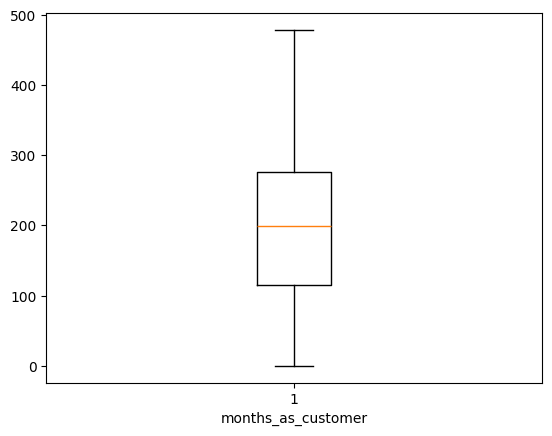

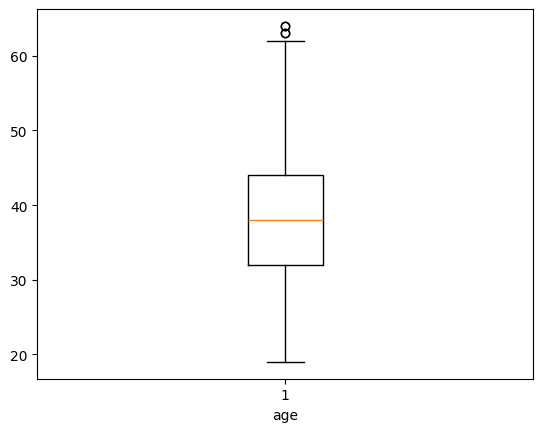

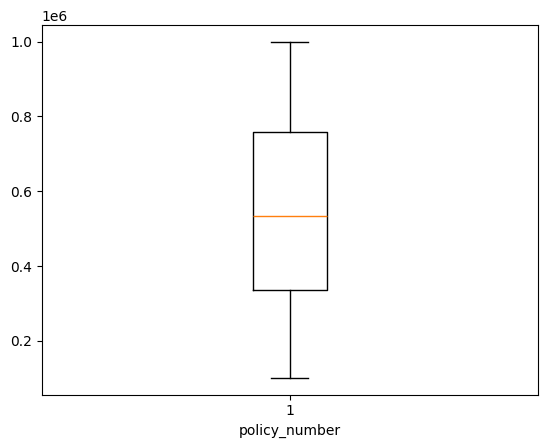

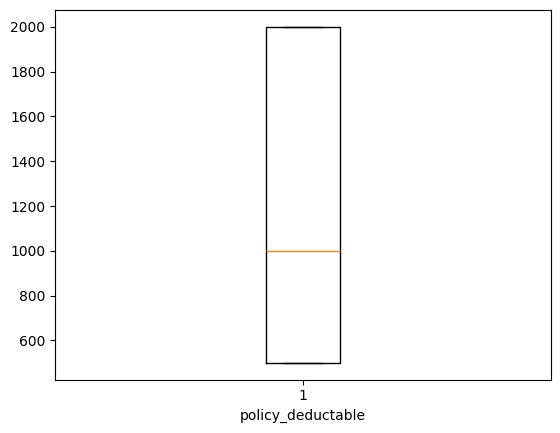

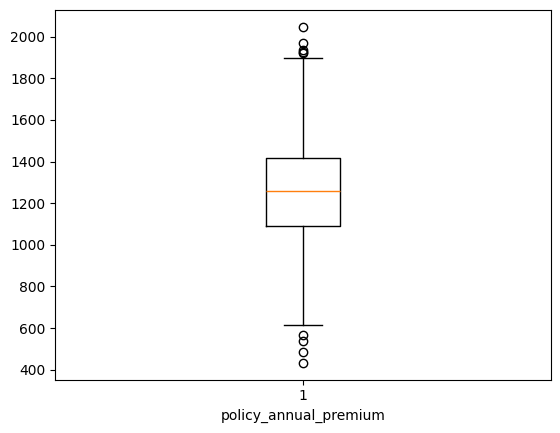

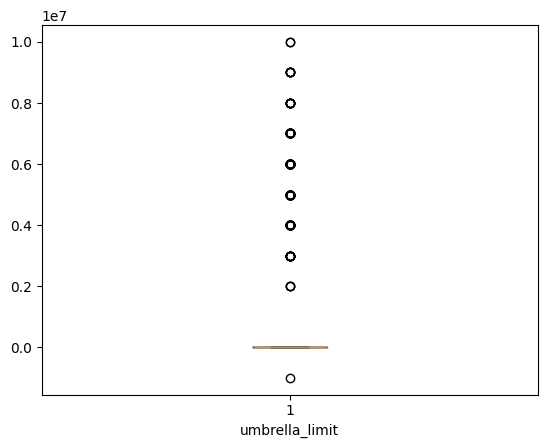

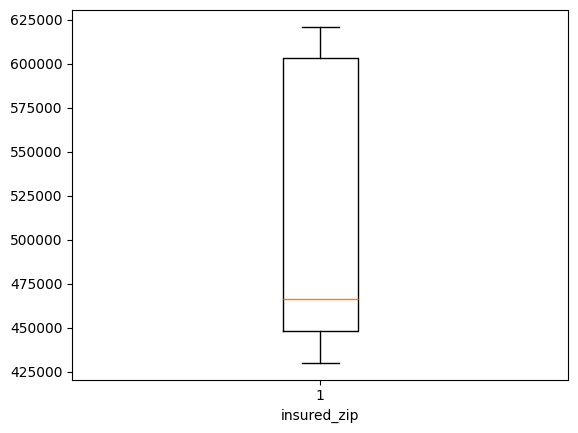

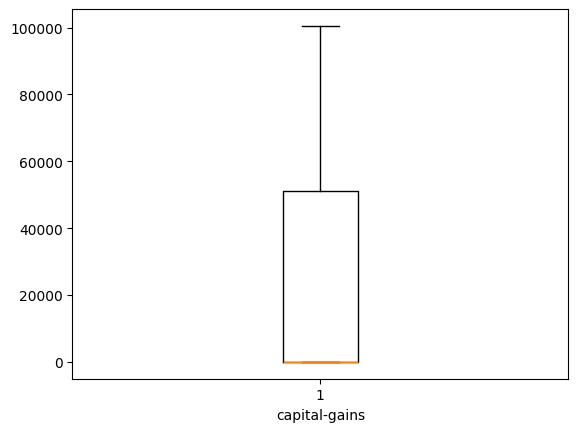

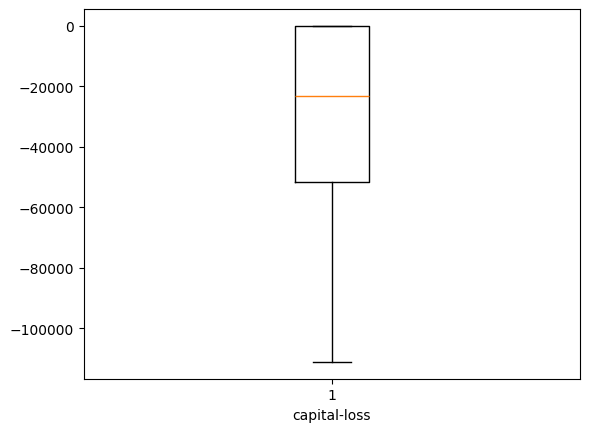

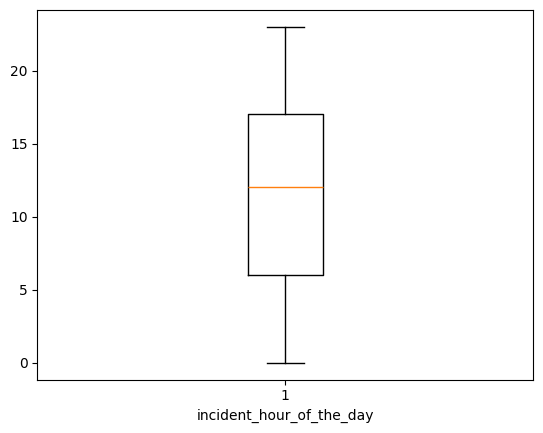

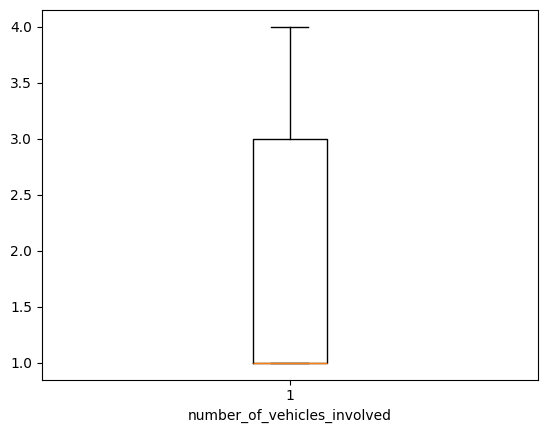

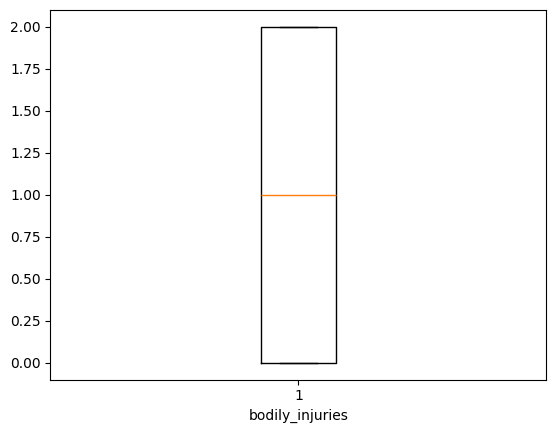

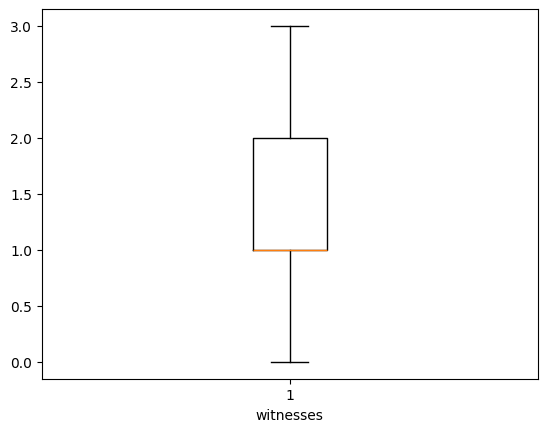

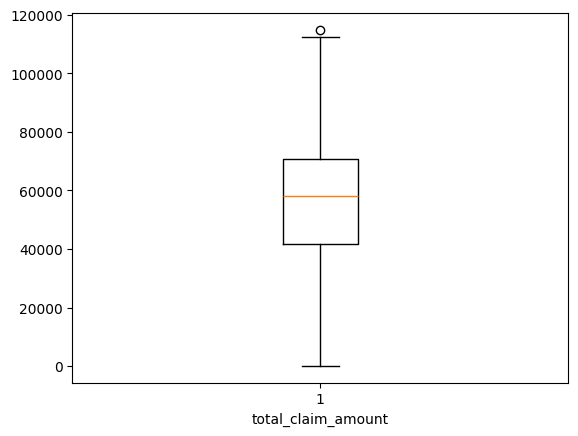

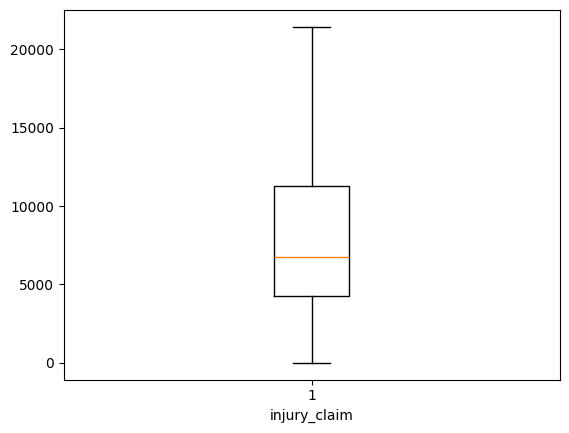

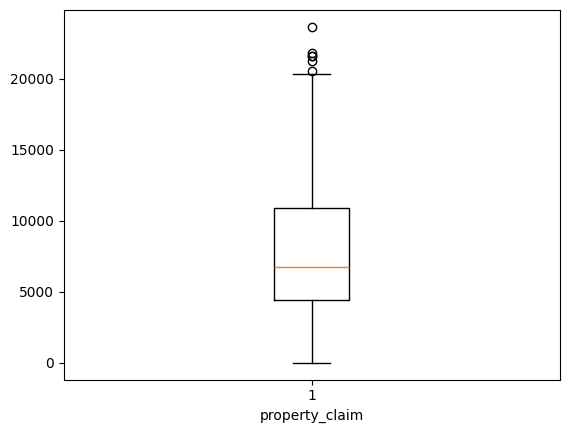

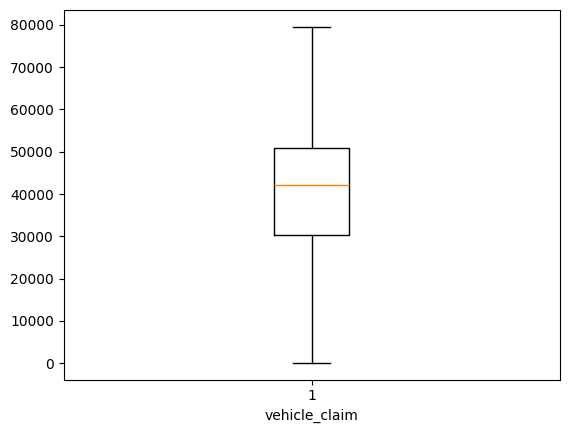

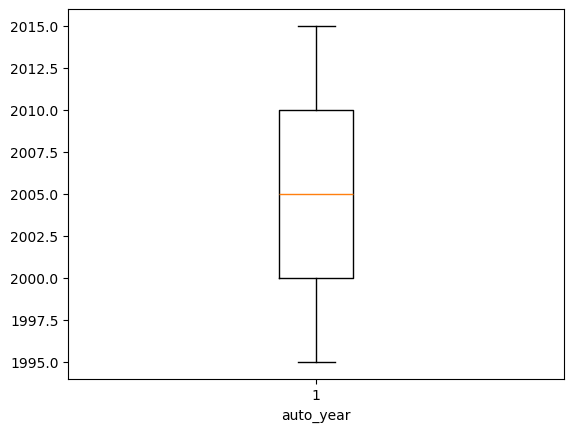

In [15]:
for i in df.columns:
   if df[i].dtype != 'object':
       plt.figure()
       plt.boxplot(df[i])
       plt.xlabel(i)

## **Feature Engineering** 

In [16]:
#fixing the date datatype

df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

In [17]:
#feature engineering for the policy_csl

# df[['csl_bodily_limit', 'csl_property_limit']] = (df['policy_csl'].str.split('/', expand=True).astype(int))

In [18]:
# extracting insights from dates present

df['policy_duration_days'] = (
     df['incident_date'] - df['policy_bind_date']
).dt.days

In [19]:
#extracting the month

df['incident_month'] = df['incident_date'].dt.month

In [20]:
#extracting the day of the week

df['incident_weekday'] = df['incident_date'].dt.dayofweek

In [21]:
# convert the value of target column from yes/no to 0 and 1

df['fraud_reported']  = np.where(df['fraud_reported'] == 'Y', 1, 0)

In [22]:
df['fraud_reported'].value_counts()

fraud_reported
0    753
1    247
Name: count, dtype: int64

In [23]:
le = LabelEncoder()

In [ ]:
#encoding the object type data for the model to process

for i in df.columns:
  if df[i].dtype=='object':
    df[i] = le.fit_transform(df[i])

In [25]:
df.shape

(1000, 42)

In [26]:
leakage_columns = ['injury_claim', 'property_claim', 'vehicle_claim']
identifier_columns = ['policy_number', 'incident_location', 'insured_zip','insured_hobbies', 'auto_model']
date_columns = ['incident_date','policy_bind_date','policy_csl']


cols_to_drop =  leakage_columns + identifier_columns + date_columns

df.drop(columns=cols_to_drop, inplace= True)


In [27]:
df.shape

(1000, 31)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_state                 1000 non-null   int64  
 3   policy_deductable            1000 non-null   int64  
 4   policy_annual_premium        1000 non-null   float64
 5   umbrella_limit               1000 non-null   int64  
 6   insured_sex                  1000 non-null   int64  
 7   insured_education_level      1000 non-null   int64  
 8   insured_occupation           1000 non-null   int64  
 9   insured_relationship         1000 non-null   int64  
 10  capital-gains                1000 non-null   int64  
 11  capital-loss                 1000 non-null   int64  
 12  incident_type                1000 non-null   int64  
 13  collision_type     

In [29]:
df

,months_as_customer,age,policy_state,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_year,fraud_reported,policy_duration_days,incident_month,incident_weekday
0,328,48,2,1000,1406.91,0,1,4,2,0,...,1,2,2,71610,10,2004,1,100,1,6
1,228,42,1,2000,1197.22,5000000,1,4,6,2,...,0,0,0,5070,8,2007,1,3130,1,2
2,134,29,2,2000,1413.14,5000000,0,6,11,3,...,2,3,1,34650,4,2007,0,5282,2,6
3,256,41,0,2000,1415.74,6000000,0,6,1,4,...,1,2,1,63400,3,2014,1,8996,1,5
4,228,44,0,1000,1583.91,6000000,1,0,11,4,...,0,1,1,6500,0,2009,0,256,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,2,1000,1310.80,0,0,5,2,4,...,0,1,0,87200,6,2006,0,8622,2,6
996,285,41,0,1000,1436.79,0,0,6,9,5,...,2,3,0,108480,13,2015,0,384,1,5
997,130,34,2,500,1383.49,3000000,0,5,1,2,...,2,3,2,67500,11,1996,0,4358,1,4
998,458,62,0,2000,1356.92,5000000,1,0,5,5,...,0,1,2,46980,1,1998,0,1196,2,3


In [30]:
corr_mat = df.corr()
corr_mat

,months_as_customer,age,policy_state,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_year,fraud_reported,policy_duration_days,incident_month,incident_weekday
months_as_customer,1.000000,0.922098,-0.000328,0.026807,0.005018,0.015498,0.060925,-0.000833,0.009814,0.069727,...,-0.010162,0.058383,0.017647,0.062108,0.047655,-0.000292,0.020544,0.047927,-0.042826,0.025674
age,0.922098,1.000000,-0.014533,0.029188,0.014404,0.018126,0.073337,0.000969,0.017220,0.074832,...,-0.015679,0.052359,0.014661,0.069863,0.030410,0.001354,0.012143,0.036742,-0.037058,0.010499
policy_state,-0.000328,-0.014533,1.000000,0.010033,0.012455,-0.029580,-0.020481,-0.034327,-0.031215,-0.018506,...,0.013384,0.022960,0.071950,-0.006002,0.017124,0.002114,0.029432,0.005589,0.018531,-0.035150
policy_deductable,0.026807,0.029188,0.010033,1.000000,-0.003245,0.010870,-0.009733,0.015217,-0.046733,-0.022945,...,-0.022765,0.066639,0.030166,0.022839,-0.035379,0.026105,0.014817,0.050396,-0.026416,-0.014399
policy_annual_premium,0.005018,0.014404,0.012455,-0.003245,1.000000,-0.006247,0.038853,-0.019715,0.035922,0.001925,...,0.026780,0.002332,0.013624,0.009094,0.000045,-0.049226,-0.014480,-0.001208,-0.046097,0.041419
umbrella_limit,0.015498,0.018126,-0.029580,0.010870,-0.006247,1.000000,0.010688,-0.019357,0.023422,0.077495,...,0.022743,-0.006738,-0.055951,-0.040344,-0.004443,0.009893,0.058622,-0.046179,-0.002576,0.011081
insured_sex,0.060925,0.073337,-0.020481,-0.009733,0.038853,0.010688,1.000000,0.009002,-0.006160,0.002855,...,-0.020297,0.042463,0.020864,-0.023727,0.026457,-0.028247,0.030873,0.032684,-0.025471,0.007351
insured_education_level,-0.000833,0.000969,-0.034327,0.015217,-0.019715,-0.019357,0.009002,1.000000,-0.020298,-0.023488,...,-0.012072,0.019211,0.036141,0.074226,0.055202,0.043509,0.008808,-0.016291,-0.053106,0.003795
insured_occupation,0.009814,0.017220,-0.031215,-0.046733,0.035922,0.023422,-0.006160,-0.020298,1.000000,-0.010171,...,-0.000236,-0.014794,-0.011083,0.003692,0.042621,-0.006676,0.001564,0.027399,-0.009459,-0.021640
insured_relationship,0.069727,0.074832,-0.018506,-0.022945,0.001925,0.077495,0.002855,-0.023488,-0.010171,1.000000,...,-0.001214,0.002362,-0.024200,0.002229,-0.027028,-0.023345,0.021043,0.005422,0.005303,-0.008001


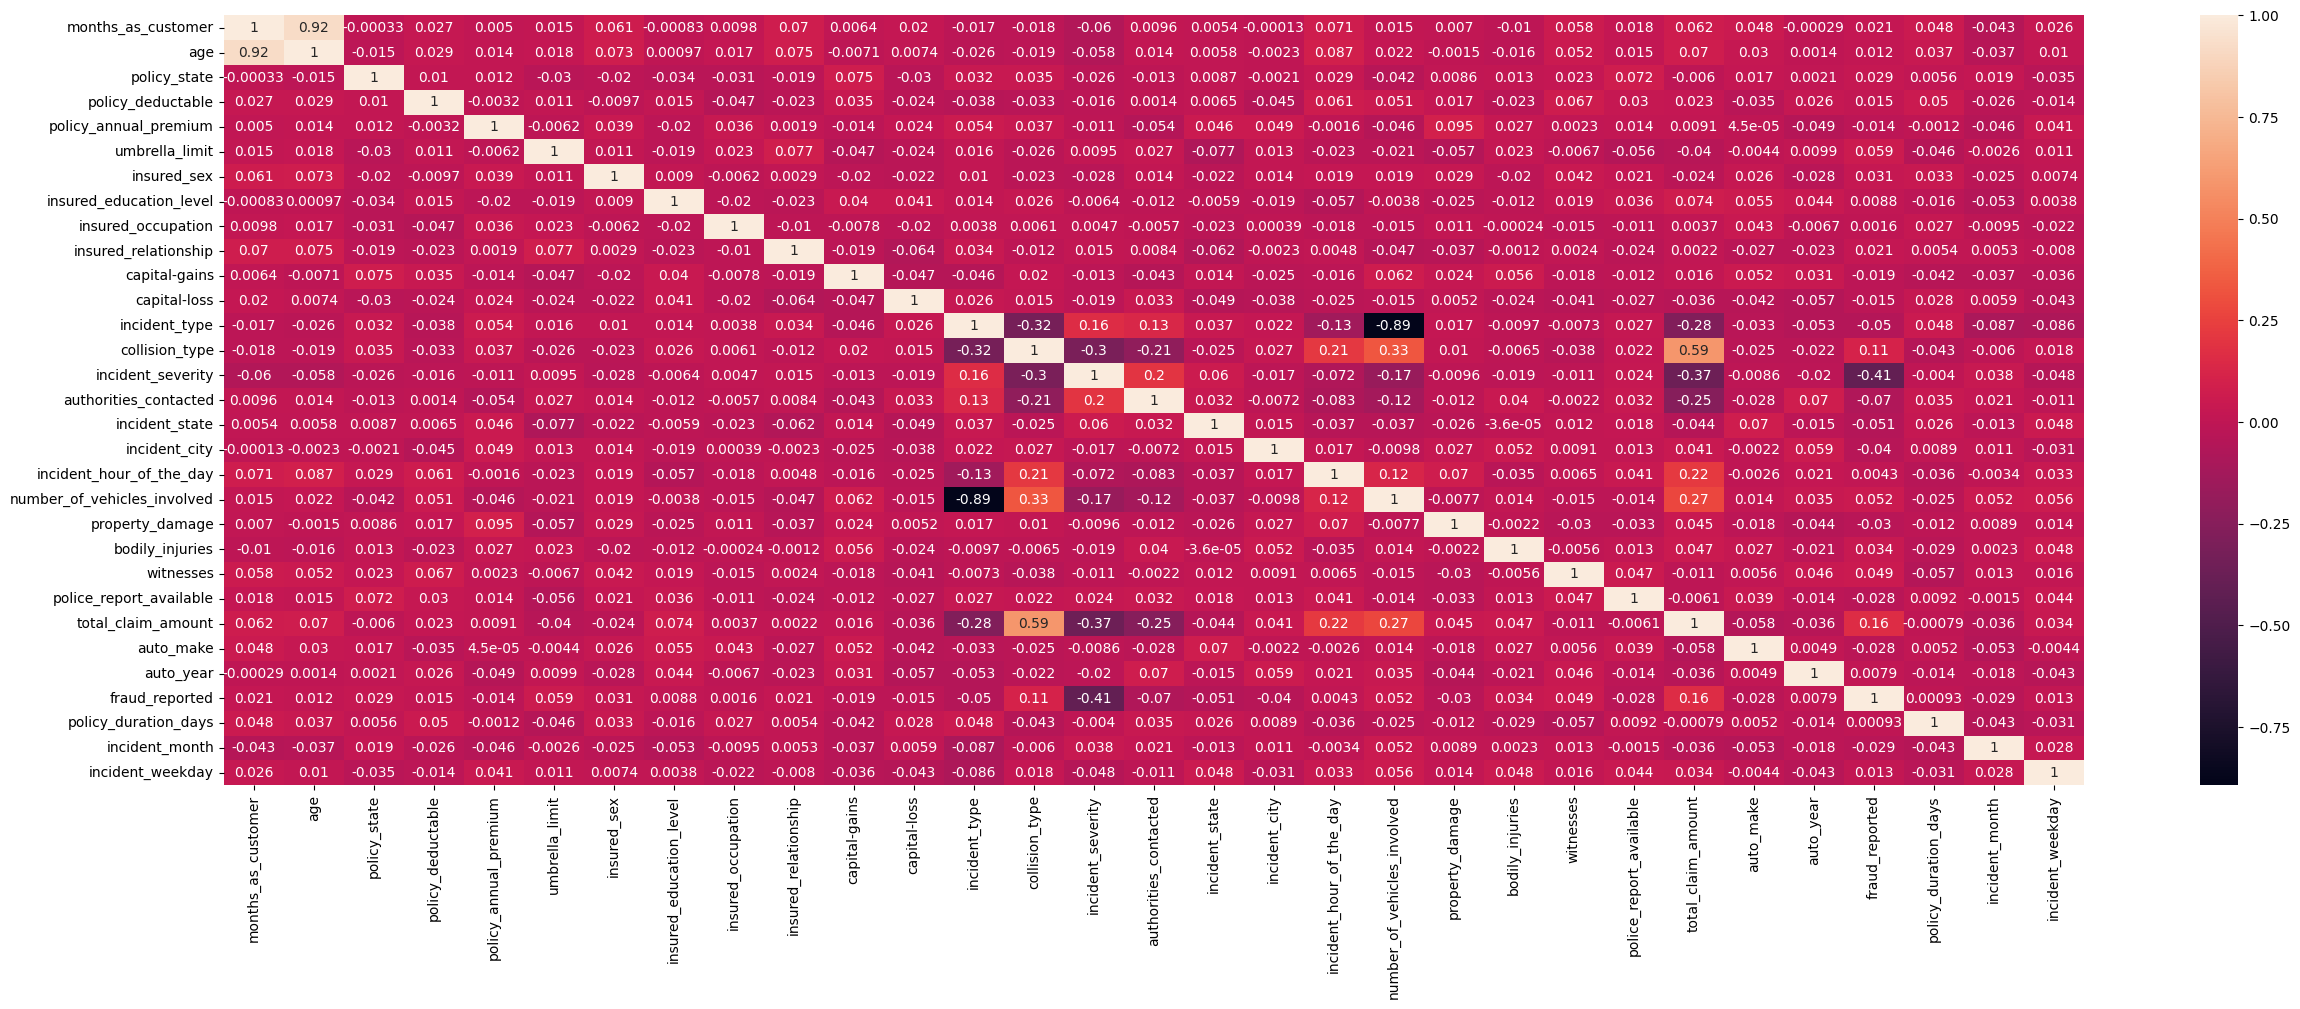

In [31]:
plt.figure(figsize=(30,10))
sns.heatmap(corr_mat, annot= True)
plt.show()

**VIF(Variance Inflation Factor)** It is a feature selection technique which calculates the multicollinearity between columns and drops the column with the highest value

In [32]:
# vif > 5 -------high multicollinearity -----------remove the column

In [33]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

In [34]:
vif_data

,Column Name,VIF Score
0,months_as_customer,28.070492
1,age,130.386864
2,policy_state,2.559898
3,policy_deductable,4.592050
4,policy_annual_premium,28.398675
5,umbrella_limit,1.270314
6,insured_sex,1.904923
7,insured_education_level,3.421178
8,insured_occupation,3.789762
9,insured_relationship,3.152406


In [35]:
df.drop('auto_year', axis= 1, inplace= True)

In [36]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,22.849448
1,age,96.313806
2,policy_state,2.530229
3,policy_deductable,4.524417
4,policy_annual_premium,24.762524
5,umbrella_limit,1.267677
6,insured_sex,1.904877
7,insured_education_level,3.374994
8,insured_occupation,3.734002
9,insured_relationship,3.116331


In [37]:
df.drop('age', axis= 1, inplace= True)

In [38]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.238877
1,policy_state,2.528302
2,policy_deductable,4.495272
3,policy_annual_premium,22.964158
4,umbrella_limit,1.266112
5,insured_sex,1.900214
6,insured_education_level,3.353174
7,insured_occupation,3.697314
8,insured_relationship,3.089781
9,capital-gains,1.864168


In [39]:
df.drop('policy_annual_premium', axis= 1, inplace= True)

In [40]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.223532
1,policy_state,2.517641
2,policy_deductable,4.467595
3,umbrella_limit,1.265055
4,insured_sex,1.894745
5,insured_education_level,3.346292
6,insured_occupation,3.645619
7,insured_relationship,3.069872
8,capital-gains,1.863478
9,capital-loss,1.964939


In [41]:
df.drop('number_of_vehicles_involved', inplace= True, axis= 1)

In [42]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.180083
1,policy_state,2.512110
2,policy_deductable,4.323107
3,umbrella_limit,1.262952
4,insured_sex,1.869535
5,insured_education_level,3.292001
6,insured_occupation,3.595956
7,insured_relationship,3.049299
8,capital-gains,1.837550
9,capital-loss,1.963658


In [43]:
df.drop('total_claim_amount', axis= 1, inplace= True)

In [44]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.125863
1,policy_state,2.511922
2,policy_deductable,4.290427
3,umbrella_limit,1.262593
4,insured_sex,1.869421
5,insured_education_level,3.227567
6,insured_occupation,3.584577
7,insured_relationship,3.041340
8,capital-gains,1.836795
9,capital-loss,1.953251


In [45]:
df.drop('incident_month', axis= 1, inplace= True)

In [46]:
vif_data = pd.DataFrame()
vif_data['Column Name'] = df.columns

vif_data['VIF Score'] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

vif_data

,Column Name,VIF Score
0,months_as_customer,4.117266
1,policy_state,2.492666
2,policy_deductable,4.255818
3,umbrella_limit,1.261656
4,insured_sex,1.868255
5,insured_education_level,3.218938
6,insured_occupation,3.547799
7,insured_relationship,3.012809
8,capital-gains,1.835977
9,capital-loss,1.952386


In [47]:
# Divide the data into x and y
X = df.drop(columns=['fraud_reported']) # independ feature
y= df['fraud_reported']

In [48]:
X

,months_as_customer,policy_state,policy_deductable,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,capital-gains,capital-loss,...,incident_state,incident_city,incident_hour_of_the_day,property_damage,bodily_injuries,witnesses,police_report_available,auto_make,policy_duration_days,incident_weekday
0,328,2,1000,0,1,4,2,0,53300,0,...,4,1,5,2,1,2,2,10,100,6
1,228,1,2000,5000000,1,4,6,2,0,0,...,5,5,8,0,0,0,0,8,3130,2
2,134,2,2000,5000000,0,6,11,3,35100,0,...,1,1,7,1,2,3,1,4,5282,6
3,256,0,2000,6000000,0,6,1,4,48900,-62400,...,2,0,5,0,1,2,1,3,8996,5
4,228,0,1000,6000000,1,0,11,4,66000,-46000,...,1,0,20,1,0,1,1,0,256,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,2,1000,0,0,5,2,4,0,0,...,0,4,20,2,0,1,0,6,8622,6
996,285,0,1000,0,0,6,9,5,70900,0,...,4,3,23,2,2,3,0,13,384,5
997,130,2,500,3000000,0,5,1,2,35100,0,...,0,0,4,0,2,3,2,11,4358,4
998,458,0,2000,5000000,1,0,5,5,0,0,...,1,0,2,0,0,1,2,1,1196,3


In [49]:
y

0      1
1      1
2      0
3      1
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: fraud_reported, Length: 1000, dtype: int64

In [50]:
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [51]:
model = LogisticRegression()

In [52]:
model.fit(X_train, y_train)

c:\Users\ritik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [53]:
y_pred = model.predict(X_test)

In [54]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [55]:
# from sklearn.metrics import accuracy_score , precision_score
from sklearn.metrics import*

In [56]:
# check the accuracy of model
accuracy_score(y_test,y_pred)

0.725